In [24]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
# Define base path
base_path = "/content/drive/MyDrive/Amali/datasets/"


# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
orders = pd.read_csv(base_path + "olist_orders_dataset.csv")
reviews = pd.read_csv(base_path + "olist_order_reviews_dataset.csv")
customers = pd.read_csv(base_path + "olist_customers_dataset.csv")
products = pd.read_csv(base_path + "olist_products_dataset.csv")
translations = pd.read_csv(base_path + "product_category_name_translation.csv")

# Optional for Candidate’s Choice
items = pd.read_csv(base_path + "olist_order_items_dataset.csv")
payments = pd.read_csv(base_path + "olist_order_payments_dataset.csv")
sellers = pd.read_csv(base_path + "olist_sellers_dataset.csv")
geolocation = pd.read_csv(base_path + "olist_geolocation_dataset.csv")


In [26]:
print(orders.head())
print(reviews.info())
print(customers.describe())
print(products.head())


                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [27]:
df = orders.merge(reviews, on="order_id", how="left")
df = df.merge(customers, on="customer_id", how="left")
df = df.merge(items[["order_id","product_id","price","freight_value"]], on="order_id", how="left")
df = df.merge(products[["product_id","product_category_name"]], on="product_id", how="left")

print("Unique orders:", df["order_id"].nunique())
print("Total rows:", len(df))


Unique orders: 99441
Total rows: 114092


In [28]:
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"])

df["days_difference"] = (df["order_estimated_delivery_date"] - df["order_delivered_customer_date"]).dt.days

def classify_delay(x):
    if pd.isnull(x): return "No Delivery"
    elif x >= 0: return "On Time"
    elif -5 <= x < 0: return "Late"
    else: return "Super Late"

df["delivery_status"] = df["days_difference"].apply(classify_delay)


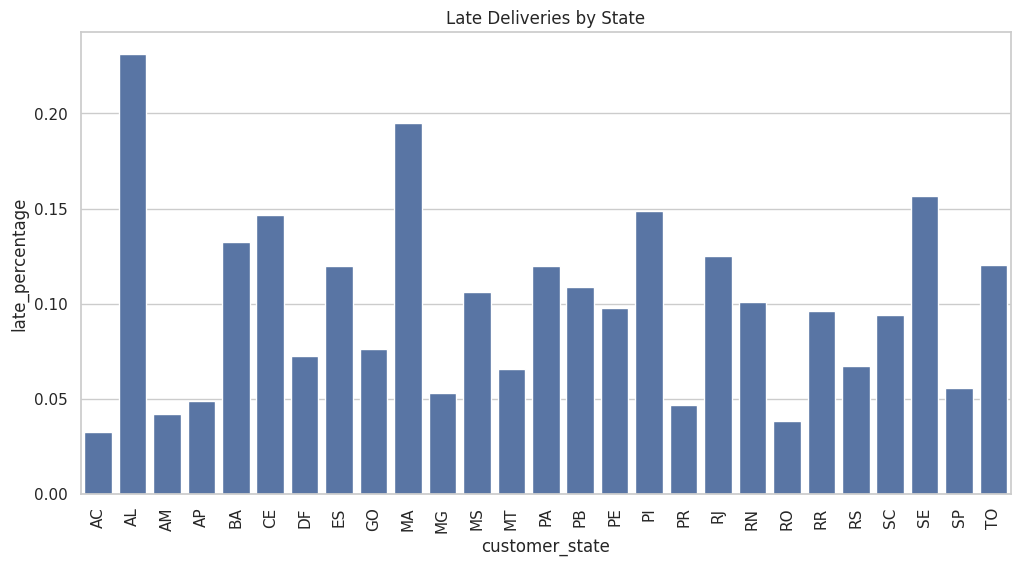

In [29]:
late_by_state = df[df["delivery_status"].isin(["Late","Super Late"])] \
    .groupby("customer_state")["order_id"].count() / df.groupby("customer_state")["order_id"].count()

late_by_state = late_by_state.reset_index().rename(columns={"order_id":"late_percentage"})

plt.figure(figsize=(12,6))
sns.barplot(data=late_by_state, x="customer_state", y="late_percentage")
plt.xticks(rotation=90)
plt.title("Late Deliveries by State")
plt.show()


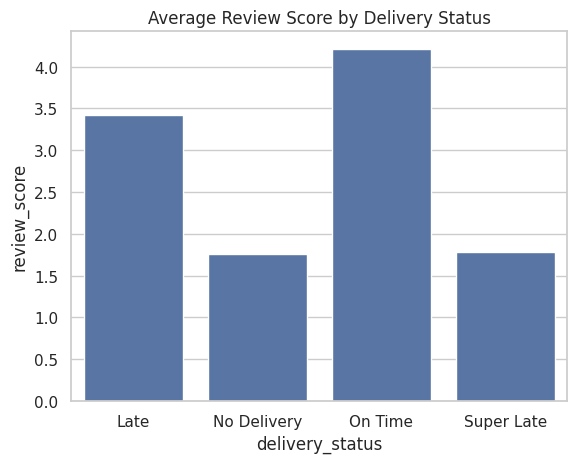

In [30]:
sentiment = df.groupby("delivery_status")["review_score"].mean().reset_index()

sns.barplot(data=sentiment, x="delivery_status", y="review_score")
plt.title("Average Review Score by Delivery Status")
plt.show()


In [31]:
df = df.merge(translations, on="product_category_name", how="left")
df[["product_category_name","product_category_name_english"]].head()


,product_category_name,product_category_name_english
0,utilidades_domesticas,housewares
1,perfumaria,perfumery
2,automotivo,auto
3,pet_shop,pet_shop
4,papelaria,stationery


In [32]:
df["total_value"] = df["price"] + df["freight_value"]

revenue_impact = df.groupby("delivery_status")["total_value"].sum().reset_index()
print(revenue_impact)


  delivery_status  total_value
0            Late    578287.41
1     No Delivery    426837.11
2         On Time  14131742.08
3      Super Late    779005.72


In [33]:
df.to_csv(base_path + "audit_clean.csv", index=False)